#IPL Data Analysis 
### Aalaysis of Indian Premier League match data

This project explores pattern in IPL matches such as team performance, toss impact, and winning trends

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [2]:
matches = pd.read_csv('../data/matches.csv')

In [3]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [4]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


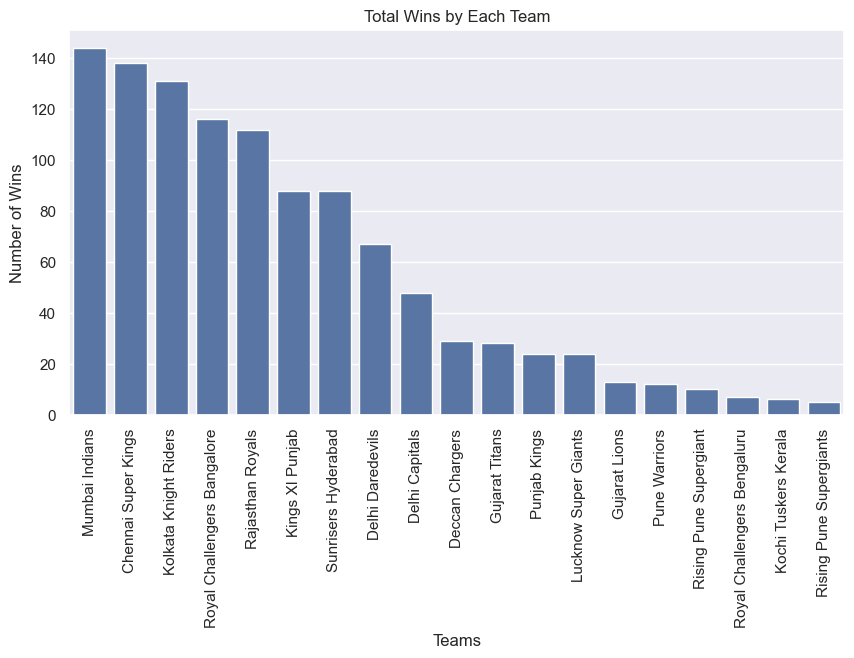

In [5]:
wins = matches['winner'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=wins.index, y=wins.values)
plt.xticks(rotation=90)
plt.title("Total Wins by Each Team")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")
plt.show()

## Insight 1: Team Performance

- Teams like Mumbai Indians and Chennai Super Kings have the highest number of wins.
- This indicates consistent performance across seasons.


In [6]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')

In [7]:
matches['toss_analysis'] = matches['toss_winner'] == matches['winner']

In [8]:
matches[['toss_winner', 'winner', 'toss_analysis']].head(10)

,toss_winner,winner,toss_analysis
0,Royal Challengers Bangalore,Kolkata Knight Riders,False
1,Chennai Super Kings,Chennai Super Kings,True
2,Rajasthan Royals,Delhi Daredevils,False
3,Mumbai Indians,Royal Challengers Bangalore,False
4,Deccan Chargers,Kolkata Knight Riders,False
5,Kings XI Punjab,Rajasthan Royals,False
6,Deccan Chargers,Delhi Daredevils,False
7,Mumbai Indians,Chennai Super Kings,False
8,Rajasthan Royals,Rajasthan Royals,True
9,Mumbai Indians,Kings XI Punjab,False


In [9]:
toss_counts= matches['toss_analysis'].value_counts()

In [10]:
print(toss_counts)

toss_analysis
True     554
False    541
Name: count, dtype: int64


In [11]:
total = toss_counts.sum()
percentage= (toss_counts[True]/total)*100
print(f"Toss winner won the match: {percentage:.2f}%")

Toss winner won the match: 50.59%


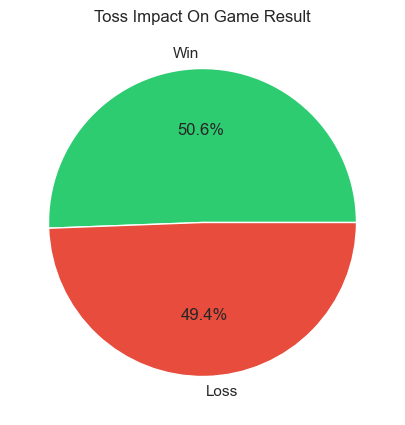

In [14]:
plt.figure(figsize=(10,5))
plt.pie(toss_counts, labels=['Win','Loss'],autopct='%1.1f%%',colors=['#2ecc71','#e74c3c'] )
plt.title('Toss Impact On Game Result')
plt.show()
